# GloFAS forecast

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [158]:
import xarray as xr
import pandas as pd

from src.datasources import glofas
from src.constants import *

In [159]:
filename = "glofas-forecast-test-2024-09-24.grib"
da = xr.load_dataset(glofas.GF_TEST_DIR / filename)["dis24"]

In [160]:
df = (
    da.to_dataframe()["dis24"]
    .reset_index()
    .drop(columns=["latitude", "longitude"])
)

In [161]:
lt2frac = {
    "2024-09-24": [
        0,
        69,
        100,
        100,
        100,
        100,
        100,
        100,
        100,
        92,
        76,
        69,
        63,
        71,
        80,
        84,
        82,
        82,
        82,
        80,
        80,
        75,
        75,
        73,
        71,
        69,
        67,
        65,
        65,
        57,
    ],
    "2024-09-23": [
        0,
        0,
        59,
        80,
        73,
        63,
        49,
        43,
        37,
        37,
        37,
        37,
        35,
        41,
        53,
        59,
        67,
        65,
        67,
        69,
        69,
        71,
        67,
        67,
        63,
        57,
        57,
        49,
        47,
        43,
    ],
}

In [162]:
df

,number,time,step,dis24
0,1,2024-09-23,1 days,4043.968750
1,1,2024-09-23,2 days,4038.898438
2,1,2024-09-23,3 days,4052.671875
3,1,2024-09-23,4 days,4065.906250
4,1,2024-09-23,5 days,4067.617188
...,...,...,...,...
2995,50,2024-09-24,26 days,3995.921875
2996,50,2024-09-24,27 days,4069.144531
2997,50,2024-09-24,28 days,4127.746094
2998,50,2024-09-24,29 days,4191.902344


In [166]:
dicts = []
dates = ["2024-09-23", "2024-09-24"]
for date in dates:
    for lt, q in enumerate(lt2frac.get(date)):
        # if lt > 15:
        #     continue
        dff = df[(df["time"] == date) & (df["step"].dt.days == lt + 1)]
        dicts.append(
            {
                "date": date,
                "lt": lt + 1,
                "thresh": dff["dis24"].quantile(1 - q / 100),
            }
        )

In [167]:
df_thresh = pd.DataFrame(dicts)
df_thresh

,date,lt,thresh
0,2024-09-23,1,4046.695312
1,2024-09-23,2,4043.437500
2,2024-09-23,3,4050.676016
3,2024-09-23,4,4051.150000
4,2024-09-23,5,4054.658984
5,2024-09-23,6,4057.040156
6,2024-09-23,7,4051.581367
7,2024-09-23,8,4061.362187
8,2024-09-23,9,4057.423984
9,2024-09-23,10,4055.635938


<Axes: >

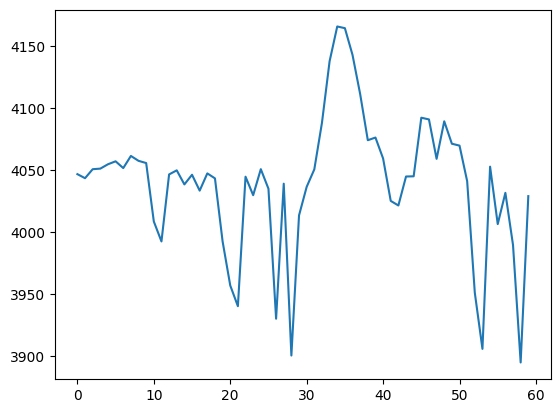

In [168]:
df_thresh["thresh"].plot()

In [169]:
df_thresh["thresh"].max()

4165.6796875

In [170]:
df_thresh["thresh"].min()

3894.9503906249997

In [171]:
df_thresh["thresh"].mean()

4039.762929036458

In [172]:
df_thresh["thresh"].median()

4046.3370703125

<Axes: >

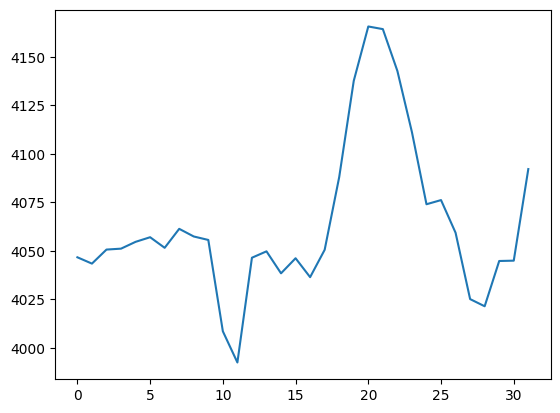

In [139]:
df_thresh["thresh"].plot()

In [149]:
thresh_2yr = df_thresh["thresh"].median()

In [150]:
df["2yr_thresh"] = df["dis24"] > thresh_2yr
df["5yr_thresh"] = df["dis24"] > NDJAMENA_5YRRP

In [151]:
ens = (
    df.groupby(["time", "step"])[[x for x in df.columns if "yr_thresh" in x]]
    .mean()
    .reset_index()
)

In [152]:
ens_pivot = ens.pivot(index="time", columns="step")

In [153]:
ens_pivot["2yr_thresh"][
    [x for x in ens_pivot["2yr_thresh"].columns if x.days <= 15]
].sort_index(ascending=False)

step,1 days,2 days,3 days,4 days,5 days,6 days,7 days,8 days,9 days,10 days,11 days,12 days,13 days,14 days,15 days
time,,,,,,,,,,,,,,,
2024-09-24,0.0,0.56,1.00,1.00,1.00,1.00,1.0,1.00,1.00,0.92,0.76,0.68,0.62,0.7,0.80
2024-09-23,0.0,0.00,0.54,0.78,0.74,0.64,0.5,0.44,0.38,0.38,0.36,0.36,0.34,0.4,0.52


In [154]:
ens_pivot["2yr_thresh"][
    [x for x in ens_pivot["2yr_thresh"].columns if x.days > 15]
].sort_index(ascending=False)

step,16 days,17 days,18 days,19 days,20 days,21 days,22 days,23 days,24 days,25 days,26 days,27 days,28 days,29 days,30 days
time,,,,,,,,,,,,,,,
2024-09-24,0.84,0.82,0.82,0.82,0.80,0.80,0.74,0.74,0.72,0.70,0.66,0.66,0.64,0.64,0.56
2024-09-23,0.58,0.66,0.64,0.66,0.68,0.68,0.70,0.66,0.66,0.62,0.56,0.54,0.48,0.46,0.42
